# Model evaluation — trench gate + YOLO detector

Two independent evaluations:

1. **DINOv2 trench classifier** (`artifacts/trench_classifier_tuned/`) on `project-resources/custom-datasets/duct-and-ruler/classification/test/` (ImageFolder layout: `trench/` + `no-trench/`).
2. **YOLO detector** (`weights/yolo11l-aug.pt`) on `project-resources/custom-datasets/duct-and-ruler-manual/detection/`:
   - Standard COCO-style detection metrics (mAP50, mAP50-95, P/R per class) via `ultralytics.YOLO.val()`.
   - Image-level binary presence (TP/FP/FN/TN, P/R/F1 per class) for `duct` and `ruler` — the metric we tune the sweep against. `whitepaper` excluded.

Both evaluations load weights from the same paths the API loads them from. The classifier and detector are evaluated independently — this notebook does NOT chain them.

In [15]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path(os.getcwd()).resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
print(f"repo root: {REPO_ROOT}")

repo root: /Users/rezafuru/repos/personal/OepenTrench


---
## 1. Trench classifier (DINOv2 + LR head)

Loads the same artifact the API consumes by default (`artifacts/trench_classifier_tuned/`). The classifier returns a calibrated score in `[0, 1]`; the threshold is read from `meta.json` (currently ~0.66, picked at training time to target P≈0.97 on CV).

DINOv2 backbone (`facebook/dinov2-small`) is fetched from HF Hub on first load.

In [16]:
from src.classifier.trench_classifier import TrenchClassifier

CLASSIFIER_ARTIFACT = REPO_ROOT / "artifacts" / "trench_classifier_tuned"
CLASSIFIER_TEST = REPO_ROOT / "project-resources/custom-datasets/duct-and-ruler/classification/test"

assert CLASSIFIER_ARTIFACT.is_dir(), f"missing artifact dir: {CLASSIFIER_ARTIFACT}"
assert CLASSIFIER_TEST.is_dir(), f"missing test set: {CLASSIFIER_TEST}"

clf = TrenchClassifier.from_artifact(CLASSIFIER_ARTIFACT)
print(f"device          {clf.device}")
print(f"model_id        {clf.meta.model_id}")
print(f"threshold       {clf.meta.threshold:.4f}")
print(f"embed_dim       {clf.meta.embed_dim}")
print(f"image_size      {clf.meta.image_size}")
print(f"train_counts    {clf.meta.train_counts}")

device          mps
model_id        facebook/dinov2-small
threshold       0.6640
embed_dim       384
image_size      224
train_counts    {'no-trench': 562, 'trench': 3343}


In [17]:
# Walk the ImageFolder layout: subdir name = class label.
IMG_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

samples: list[tuple[Path, str]] = []
for class_dir in sorted(CLASSIFIER_TEST.iterdir()):
    if not class_dir.is_dir() or class_dir.name.startswith((".", "_")):
        continue
    label = class_dir.name
    for img_path in sorted(class_dir.iterdir()):
        if img_path.suffix.lower() in IMG_EXTS and not img_path.name.startswith("."):
            samples.append((img_path, label))

print(f"loaded {len(samples)} samples")
for label in sorted({s[1] for s in samples}):
    n = sum(1 for _, lbl in samples if lbl == label)
    print(f"  {label}: {n}")

loaded 30 samples
  no-trench: 15
  trench: 15


In [18]:
# Run the classifier over every test image; collect score + ground truth.
rows = []
for img_path, label in samples:
    is_trench, score = clf.predict(img_path)
    rows.append({
        "path": str(img_path.relative_to(REPO_ROOT)),
        "label": label,                # "trench" or "no-trench"
        "y_true": int(label == "trench"),
        "score": score,                # P(trench)
        "y_pred_at_meta_threshold": int(is_trench),
    })

clf_df = pd.DataFrame(rows)
clf_df.head()

,path,label,y_true,score,y_pred_at_meta_threshold
0,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.881161,1
1,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.172835,0
2,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.441616,0
3,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.987497,1
4,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.345050,0


In [19]:
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

y_true = clf_df["y_true"].values
y_score = clf_df["score"].values
y_pred = clf_df["y_pred_at_meta_threshold"].values

thr = clf.meta.threshold
cm = confusion_matrix(y_true, y_pred)  # rows = true (0=no-trench, 1=trench)
tn, fp, fn, tp = cm.ravel()

print(f"# at meta-threshold = {thr:.4f}")
print(f"  accuracy  {accuracy_score(y_true, y_pred):.4f}")
print(f"  precision {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  recall    {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  F1        {f1_score(y_true, y_pred, zero_division=0):.4f}")
print()
print(f"# threshold-independent")
print(f"  ROC-AUC   {roc_auc_score(y_true, y_score):.4f}")
print(f"  PR-AUC    {average_precision_score(y_true, y_score):.4f}")
print()
print("# confusion matrix (rows=true, cols=pred)")
print(pd.DataFrame(cm, index=["no-trench", "trench"], columns=["no-trench", "trench"]))

# at meta-threshold = 0.6640
  accuracy  0.7667
  precision 0.7222
  recall    0.8667
  F1        0.7879

# threshold-independent
  ROC-AUC   0.8800
  PR-AUC    0.8844

# confusion matrix (rows=true, cols=pred)
           no-trench  trench
no-trench         10       5
trench             2      13


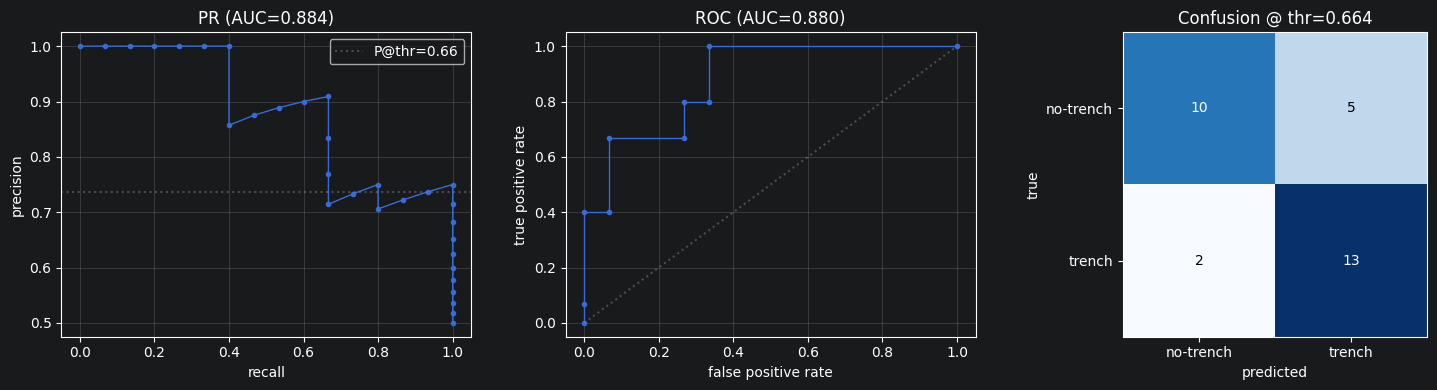

In [20]:
# Visualisation: PR curve + ROC + confusion matrix.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
axes[0].plot(recall, precision, marker=".", linewidth=1)
axes[0].axhline(precision[np.argmin(np.abs(pr_thresholds - thr))] if len(pr_thresholds) else 0,
                color="grey", linestyle=":", alpha=0.5, label=f"P@thr={thr:.2f}")
axes[0].set_xlabel("recall")
axes[0].set_ylabel("precision")
axes[0].set_title(f"PR (AUC={average_precision_score(y_true, y_score):.3f})")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

fpr, tpr, _ = roc_curve(y_true, y_score)
axes[1].plot(fpr, tpr, marker=".", linewidth=1)
axes[1].plot([0, 1], [0, 1], color="grey", linestyle=":", alpha=0.5)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title(f"ROC (AUC={roc_auc_score(y_true, y_score):.3f})")
axes[1].grid(True, alpha=0.3)

im = axes[2].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["no-trench", "trench"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["no-trench", "trench"])
axes[2].set_xlabel("predicted"); axes[2].set_ylabel("true")
axes[2].set_title(f"Confusion @ thr={thr:.3f}")
plt.tight_layout()
plt.show()

In [21]:
# Inspect misclassified samples.
mis = clf_df[clf_df["y_true"] != clf_df["y_pred_at_meta_threshold"]].copy()
mis["kind"] = np.where(mis["y_true"] == 1, "false_negative", "false_positive")
mis.sort_values(["kind", "score"], ascending=[True, False])

,path,label,y_true,score,y_pred_at_meta_threshold,kind
27,project-resources/custom-datasets/duct-and-rul...,trench,1,0.660436,0,false_negative
23,project-resources/custom-datasets/duct-and-rul...,trench,1,0.588907,0,false_negative
3,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.987497,1,false_positive
7,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.934519,1,false_positive
11,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.906600,1,false_positive
0,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.881161,1,false_positive
5,project-resources/custom-datasets/duct-and-rul...,no-trench,0,0.725484,1,false_positive


---
## 2. YOLO detector

Weights loaded from `weights/yolo11l-aug.pt` — the same default `yolo_detection_service.py` uses. The detection test set is `project-resources/custom-datasets/duct-and-ruler-manual/detection/images/test` (75 images).

Evaluated in two passes:

**2a. Standard object-detection metrics** — `ultralytics.YOLO.val()` computes COCO-style mAP@0.5, mAP@0.5:0.95, and per-class precision/recall. Bounding boxes are matched to GT by IoU≥threshold.

**2b. Image-level binary presence** — reduce both GT and predictions to one yes/no per image per class (≥1 box of that class). TP/FP/FN/TN and P/R/F1 per class. `whitepaper` excluded — only `duct` and `ruler` are scored, matching the sweep optimization target.

In [22]:
from ultralytics import YOLO

WEIGHTS = REPO_ROOT / "weights" / "yolo11l-aug.pt"
DATA_YAML = REPO_ROOT / "project-resources/custom-datasets/duct-and-ruler-manual/detection/data.yaml"
TEST_IMG  = REPO_ROOT / "project-resources/custom-datasets/duct-and-ruler-manual/detection/images/test"
TEST_LBL  = REPO_ROOT / "project-resources/custom-datasets/duct-and-ruler-manual/detection/labels/test"

assert WEIGHTS.is_file(), f"missing weights: {WEIGHTS}"
assert DATA_YAML.is_file(), f"missing data.yaml: {DATA_YAML}"
assert TEST_IMG.is_dir(), f"missing test images: {TEST_IMG}"
assert TEST_LBL.is_dir(), f"missing test labels: {TEST_LBL}"

yolo = YOLO(str(WEIGHTS))
print(f"loaded {WEIGHTS.name}")
print(f"classes: {yolo.names}")

loaded yolo11l-aug.pt
classes: {0: 'duct', 1: 'ruler', 2: 'whitepaper'}


### 2a. Standard object detection metrics

`model.val()` reads the `val:` split from the data.yaml (currently `images/test`), runs predictions, and computes COCO-style metrics. Each class is reported separately.

In [23]:
val_results = yolo.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=640,
    conf=0.001,   # ultralytics default for mAP computation (sweeps internally)
    iou=0.7,
    save_json=False,
    plots=False,
    verbose=False,
)

box = val_results.box
names = val_results.names
rows = []
for cls_id in range(len(box.maps)):
    rows.append({
        "class":      names[cls_id],
        "images":     int(box.nt_per_class[cls_id]) if hasattr(box, "nt_per_class") else None,
        "instances":  int(box.nt_per_image[cls_id]) if hasattr(box, "nt_per_image") else None,
        "precision":  float(box.p[cls_id]) if cls_id < len(box.p) else None,
        "recall":     float(box.r[cls_id]) if cls_id < len(box.r) else None,
        "mAP50":      float(box.ap50[cls_id]) if cls_id < len(box.ap50) else None,
        "mAP50-95":   float(box.maps[cls_id]),
    })
rows.append({
    "class": "all",
    "images": None, "instances": None,
    "precision": float(box.mp), "recall": float(box.mr),
    "mAP50": float(box.map50), "mAP50-95": float(box.map),
})
detection_df = pd.DataFrame(rows)
detection_df.style.format({
    "precision": "{:.3f}", "recall": "{:.3f}",
    "mAP50": "{:.3f}", "mAP50-95": "{:.3f}",
})

Ultralytics 8.4.51 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M5 Pro)
YOLO11l summary (fused): 191 layers, 25,281,625 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7866.8±2154.6 MB/s, size: 504.2 KB)
val: Scanning /Users/rezafuru/repos/personal/OepenTrench/project-resources/custom-datasets/duct-and-ruler-manual/detection/labels/test.cache... 75 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 35.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.4s/it 51.9s16.2s
                   all         75        150      0.588       0.42      0.394      0.255
Speed: 0.2ms preprocess, 678.4ms inference, 0.0ms loss, 0.2ms postprocess per image


,class,images,instances,precision,recall,mAP50,mAP50-95
0,duct,None,None,0.473,0.320,0.250,0.106
1,ruler,None,None,0.465,0.240,0.238,0.126
2,whitepaper,None,None,0.825,0.700,0.696,0.533
3,all,None,None,0.588,0.420,0.394,0.255


### 2b. Image-level binary presence (duct + ruler, whitepaper excluded)

For each image we ask: does the model detect ≥1 box of class X, and is there ≥1 GT box of class X? Bounding-box geometry and instance counts are ignored. This is the metric the sweep optimizes.

Inference conf threshold is `0.10` — the Phase-0 sweet spot (~max F1 with FPs > FNs).

In [24]:
PRESENCE_CONF = 0.10
TARGET_CLASSES = ("duct", "ruler")   # whitepaper excluded
CLASS_NAMES = [yolo.names[i] for i in range(max(yolo.names) + 1)]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}

def classes_in_yolo_label_file(path: Path) -> set[str]:
    if not path.is_file():
        return set()
    out: set[str] = set()
    for line in path.read_text().splitlines():
        parts = line.strip().split()
        if not parts:
            continue
        try:
            cls_id = int(parts[0])
        except ValueError:
            continue
        if 0 <= cls_id < len(CLASS_NAMES):
            out.add(CLASS_NAMES[cls_id])
    return out

# Predict over the test set and reduce each image's prediction to a class set.
img_paths = sorted(
    p for p in TEST_IMG.iterdir()
    if p.suffix.lower() in IMG_EXTS and not p.name.startswith(".")
)
print(f"predicting on {len(img_paths)} test images @ conf={PRESENCE_CONF}")
pred_results = yolo.predict(
    source=[str(p) for p in img_paths],
    conf=PRESENCE_CONF,
    save=False, save_txt=False,
    verbose=False,
)

presence_rows = []
for img_path, res in zip(img_paths, pred_results):
    gt_classes = classes_in_yolo_label_file(TEST_LBL / f"{img_path.stem}.txt")
    if res.boxes is not None and len(res.boxes) > 0:
        pred_classes = {
            CLASS_NAMES[int(c.item())]
            for c in res.boxes.cls
        }
    else:
        pred_classes = set()
    row = {"image": img_path.name}
    for cls in TARGET_CLASSES:
        row[f"gt_{cls}"] = int(cls in gt_classes)
        row[f"pred_{cls}"] = int(cls in pred_classes)
    presence_rows.append(row)

presence_df = pd.DataFrame(presence_rows)
presence_df.head()

predicting on 75 test images @ conf=0.1


,image,gt_duct,pred_duct,gt_ruler,pred_ruler
0,1_IMG-20240814-WA0046.jpg,0,0,0,0
1,1_WhatsApp_Image_2024-08-26_at_18_18_39.jpeg,1,1,0,0
2,1_WhatsApp_Image_2024-09-02_at_21_21_54.jpeg,0,0,0,0
3,1_WhatsApp_Image_2024-09-03_at_18_46_42__3_.jpeg,0,0,0,0
4,1_WhatsApp_Image_2024-09-04_at_22_33_36.jpeg,0,0,0,0


In [25]:
def div(num, den):
    return num / den if den else 0.0

presence_metrics = []
for cls in TARGET_CLASSES:
    g = presence_df[f"gt_{cls}"].astype(bool)
    p = presence_df[f"pred_{cls}"].astype(bool)
    tp = int(( g &  p).sum())
    fp = int((~g &  p).sum())
    fn = int(( g & ~p).sum())
    tn = int((~g & ~p).sum())
    presence_metrics.append({
        "class": cls,
        "P_GT":   int(g.sum()),
        "P_pred": int(p.sum()),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": div(tp, tp + fp),
        "recall":    div(tp, tp + fn),
        "F1":        div(2 * tp, 2 * tp + fp + fn),
        "accuracy":  div(tp + tn, tp + fp + fn + tn),
    })
presence_metrics_df = pd.DataFrame(presence_metrics)
presence_metrics_df.style.format({
    "precision": "{:.3f}", "recall": "{:.3f}",
    "F1": "{:.3f}", "accuracy": "{:.3f}",
})

,class,P_GT,P_pred,TP,FP,FN,TN,precision,recall,F1,accuracy
0,duct,50,51,48,3,2,22,0.941,0.960,0.950,0.933
1,ruler,50,38,38,0,12,25,1.000,0.760,0.864,0.840


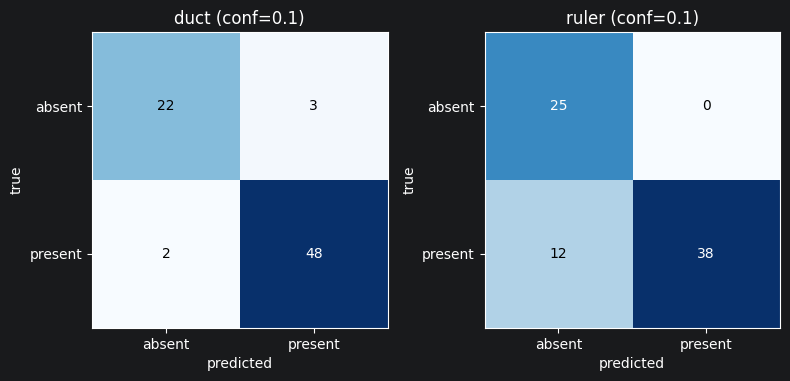

In [26]:
# Per-class confusion matrices for the presence metric.
fig, axes = plt.subplots(1, len(TARGET_CLASSES), figsize=(4 * len(TARGET_CLASSES), 4))
if len(TARGET_CLASSES) == 1:
    axes = [axes]
for ax, cls in zip(axes, TARGET_CLASSES):
    g = presence_df[f"gt_{cls}"].astype(bool)
    p = presence_df[f"pred_{cls}"].astype(bool)
    cm = np.array([
        [int((~g & ~p).sum()), int((~g &  p).sum())],
        [int(( g & ~p).sum()), int(( g &  p).sum())],
    ])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["absent", "present"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["absent", "present"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{cls} (conf={PRESENCE_CONF})")
plt.tight_layout()
plt.show()

In [27]:
# Quick threshold sweep for the presence metric (useful for picking the operating point).
sweep_rows = []
for conf in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    res_at = yolo.predict(source=[str(p) for p in img_paths], conf=conf,
                          save=False, save_txt=False, verbose=False)
    for cls in TARGET_CLASSES:
        tp = fp = fn = tn = 0
        for img_path, res in zip(img_paths, res_at):
            gt = cls in classes_in_yolo_label_file(TEST_LBL / f"{img_path.stem}.txt")
            pred = res.boxes is not None and any(
                CLASS_NAMES[int(c.item())] == cls for c in res.boxes.cls
            )
            if gt and pred:       tp += 1
            elif not gt and pred: fp += 1
            elif gt and not pred: fn += 1
            else:                 tn += 1
        sweep_rows.append({
            "conf": conf, "class": cls,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": div(tp, tp + fp),
            "recall":    div(tp, tp + fn),
            "F1":        div(2 * tp, 2 * tp + fp + fn),
        })

conf_sweep_df = pd.DataFrame(sweep_rows)
conf_sweep_df.pivot(index="conf", columns="class", values=["F1", "precision", "recall"]).round(3)

F1        precision        recall      
class   duct  ruler      duct  ruler   duct ruler
conf                                             
0.05   0.952  0.870     0.909  0.952   1.00  0.80
0.10   0.950  0.864     0.941  1.000   0.96  0.76
0.15   0.928  0.795     0.957  1.000   0.90  0.66
0.20   0.882  0.780     0.953  1.000   0.82  0.64
0.25   0.841  0.718     0.974  1.000   0.74  0.56
0.30   0.658  0.684     0.962  1.000   0.50  0.52

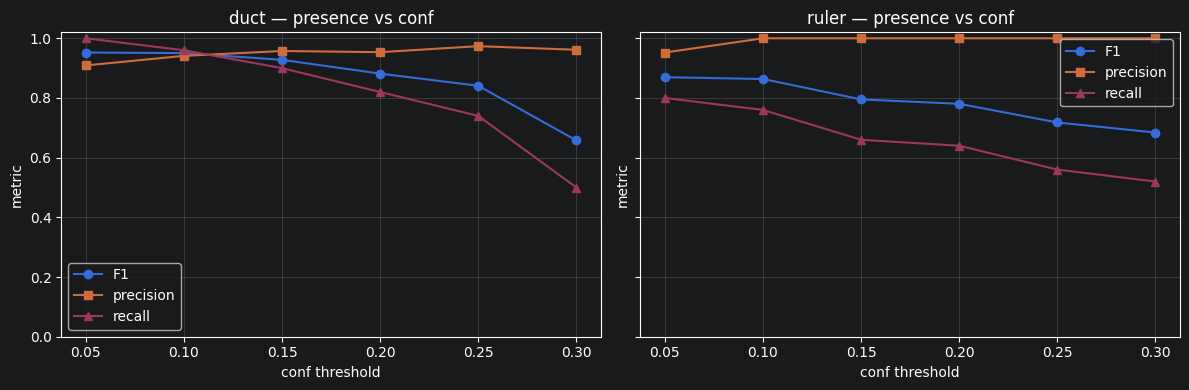

In [28]:
# Plot the F1/precision/recall vs conf-threshold per class.
fig, axes = plt.subplots(1, len(TARGET_CLASSES), figsize=(6 * len(TARGET_CLASSES), 4), sharey=True)
if len(TARGET_CLASSES) == 1:
    axes = [axes]
for ax, cls in zip(axes, TARGET_CLASSES):
    sub = conf_sweep_df[conf_sweep_df["class"] == cls]
    ax.plot(sub["conf"], sub["F1"],        marker="o", label="F1")
    ax.plot(sub["conf"], sub["precision"], marker="s", label="precision")
    ax.plot(sub["conf"], sub["recall"],    marker="^", label="recall")
    ax.set_xlabel("conf threshold"); ax.set_ylabel("metric")
    ax.set_title(f"{cls} — presence vs conf")
    ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

- **Trench classifier**: see metrics + PR/ROC above. Trained-time CV target was P≈0.97; this notebook reports the held-out test number.
- **YOLO detector standard metrics**: COCO mAP per class. `whitepaper` is included here for completeness (we still train on it; just ignore it when picking sweep winners).
- **YOLO detector presence metric**: per-class P/R/F1 with `duct` and `ruler` only. The sweep optimises against the same metric (at conf=0.10); the conf-sweep plot at the bottom shows whether 0.10 is still the right operating point for the current weight.